In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
weekly_df = pd.read_csv(
    "prepared_data/weekly_df.csv",
    index_col=0,
    parse_dates=True
)

# Optional: ensure index is sorted and unique
weekly_df = weekly_df[~weekly_df.index.duplicated(keep="first")].sort_index()

print("Shape:", weekly_df.shape)

Shape: (1135, 49)


### Variable Mapping

In [3]:
summary = []
for c in weekly_df.columns:
    s = weekly_df[c].dropna()
    if len(s) == 0:
        continue
    summary.append({
        "col": c,
        "n": len(s),
        "min": float(s.min()),
        "median": float(s.median()),
        "max": float(s.max()),
    })

diag = pd.DataFrame(summary).reset_index(drop=True)

# round numeric cols to 2 decimals so you don't get scientific notation
num_cols = ["min", "median", "max"]
diag[num_cols] = diag[num_cols].round(2)

print(diag.to_string(index=False))

                          col    n       min     median        max
                        SP500 1135    683.38    2003.37    6929.94
                          VIX 1135      9.14      16.40      79.13
                       RV_30D 1135      0.04       0.13       0.85
                       IV_VAR 1135      0.01       0.03       0.63
                   RV_30D_VAR 1135      0.00       0.02       0.72
                          VRP 1135     -0.55       0.01       0.20
                WTI_Crude_Oil 1135     16.94      68.99     145.29
                  Natural_Gas 1135      1.50       3.67      14.31
                       Copper 1135      1.18       3.18       5.77
                         Gold 1135    377.00    1297.00    4529.10
                       Silver 1135      5.59      17.80      76.49
                      USD_JPY 1135     75.72     109.75     160.88
                      USD_CHF 1135      0.76       0.97       1.32
            Japan_Policy_Rate 1135     -0.07       0.07       

In [4]:
# =====================================================
# HARD-CODED GROUPS (manual, ver q tipo es cada variable)
# =====================================================
RATE_LIKE = [
    "Japan_Policy_Rate",
    "Japan_10Y_JGB",
    "Unemployment_Rate",
    "IG_OAS_Spread",
    "CPI_YoY",
    "Core_CPI_YoY",
    "Core_minus_Headline_Inflation",
    "Expected_Inflation_5Y",
    "Expected_Inflation_10Y",
    "US_10Y_Treasury",
    "US_2Y_Treasury",
    "US_3M_Treasury",
    "US_10Y_Real_Yield",
    # "AAA_Yield","BBB_Yield","HY_Yield","US10Y_Yield",
    # "CP_3M","TBILL_3M",
    
    "BBB_AAA_Credit_Spread",
    "High_Yield_Spread",
    "Short_Term_Credit_Spread",
    "Long_Term_Credit_Spread",
    "Credit_Spread_Term_Struct",
    "Spread_10Y_2Y",
    "Spread_10Y_3M",
]

SPECIAL_LIKE = [
    "VIX",
    "RV_30D",
    "IV_VAR",
    "RV_30D_VAR",
    "VRP",
    "NFCI",
    "Sector_Rotation",
]

LEVEL_LIKE = [
    "SP500",
    # "XLK","XLY","XLI","XLF","XLB","XLE","XLP","XLU","XLV",
    "WTI_Crude_Oil","Natural_Gas","Copper","Gold","Silver",
    "USD_JPY","USD_CHF",
    "Industrial_Production","Consumer_Sentiment",
    "CPI","Core_CPI",
    "Fed_Total_Assets","Treasury_General_Account","Bank_Reserves",
    "Building_Permits",
    "Retail_Sales",
]

TREND_LIKE = [
    "foodbanks_near_me",
    "help_with_mortgage",
    "resume_template",
    "sell_jewelry",
    "credit_card_debt",
]


def check_var_lists(df_cols, rate_like, special_like, level_like, trend_like, warn_extras_in_lists=True):
    df_cols = list(df_cols)

    groups = {
        "RATE_LIKE": set(rate_like),
        "SPECIAL_LIKE": set(special_like),
        "LEVEL_LIKE": set(level_like),
        "TREND_LIKE": set(trend_like),
    }

    # Overlaps across groups
    overlaps = []
    keys = list(groups.keys())
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            a, b = keys[i], keys[j]
            inter = groups[a] & groups[b]
            if inter:
                overlaps.append((a, b, sorted(inter)))

    # Unclassified dataframe columns
    union_groups = set().union(*groups.values())
    unclassified = sorted(set(df_cols) - union_groups)

    print("\n=== LIST CHECK (weekly_df.columns as truth) ===")
    if overlaps:
        print("❌ Overlaps (vars appear in multiple groups):")
        for a, b, inter in overlaps:
            print(f"  {a} ∩ {b}: {inter}")
    else:
        print("✅ No overlaps between groups.")

    if unclassified:
        print("\n❌ Unclassified columns (in weekly_df but in 0 lists):")
        print(" ", unclassified)
    else:
        print("\n✅ All weekly_df columns are classified into a group.")

    # Extras: vars in lists but not present in weekly_df
    if warn_extras_in_lists:
        df_set = set(df_cols)
        extras = {k: sorted(v - df_set) for k, v in groups.items()}
        if any(extras[k] for k in extras):
            print("\n❌ Vars in lists but NOT in weekly_df.columns (ok, but maybe outdated):")
            for k, v in extras.items():
                if v:
                    print(f"  {k}: {v}")
        else:
            print("\n✅ No list contains vars outside weekly_df.columns.")


# Run (NOTE: weekly_df, not weekly_df)
check_var_lists(weekly_df.columns, RATE_LIKE, SPECIAL_LIKE, LEVEL_LIKE, TREND_LIKE)


=== LIST CHECK (weekly_df.columns as truth) ===
✅ No overlaps between groups.

✅ All weekly_df columns are classified into a group.

✅ No list contains vars outside weekly_df.columns.


### Variable Y

In [5]:
# =====================================================
# Y binaria vol-adjusted (4 semanas) con weekly_df
# 0 = OUT  -> caída fuerte
# 1 = IN   -> no caída fuerte
# =====================================================

H = 4
VOL_WIN = 26
K = 0.5 #factor de ajuste

sp = weekly_df["SP500"].astype(float)

y_h = (sp.shift(-H) / sp - 1).rename(f"y_SP500_ret_fwd_{H}w") #cambio % de H semanas
r1 = sp.pct_change(1) #retorno % semanal
sigma1 = r1.rolling(VOL_WIN).std() #volatilidad semanal reciente
tau = K * sigma1 * np.sqrt(H) #umbral (formula) 

# empezar vacía
y_bin = pd.Series(np.nan, index=weekly_df.index, name=f"y_SP500_bin_{H}w")
# máscara válida: solo donde existen y_h y tau
valid = y_h.notna() & tau.notna()
# asignar 0/1 solo en esas fechas
y_bin.loc[valid] = (y_h.loc[valid] >= -tau.loc[valid]).astype(int)

# dataframe final
weekly_df_1m = pd.concat([weekly_df, y_h, y_bin], axis=1).dropna()

print(weekly_df_1m[["SP500", f"y_SP500_ret_fwd_{H}w", f"y_SP500_bin_{H}w"]].head())
print(weekly_df_1m[f"y_SP500_bin_{H}w"].value_counts())

                  SP500  y_SP500_ret_fwd_4w  y_SP500_bin_4w
2004-10-01  1131.500000           -0.001149             1.0
2004-10-08  1122.140015            0.039238             1.0
2004-10-15  1108.199951            0.068553             1.0
2004-10-22  1095.739990            0.068082             1.0
2004-10-29  1130.199951            0.046408             1.0
y_SP500_bin_4w
1.0    877
0.0    228
Name: count, dtype: int64


### Justificacion Vars X

acf y pacf, para justficar el grid: hay efecto temporal

In [6]:
# =====================================================
# ACF / PACF PRELIMINAR
# - LEVEL_LIKE   -> pct_change(1)
# - resto        -> diff(1)
# =====================================================

from statsmodels.tsa.stattools import acf, pacf
from collections import Counter

MAX_LAG = 52  # un años

def series_for_time_test(var_name):
    x = weekly_df[var_name].astype(float)

    if var_name in LEVEL_LIKE:
        s = x.pct_change(1)
    else:
        s = x.diff(1)

    return s.replace([np.inf, -np.inf], np.nan).dropna()

rows = []
acf_counter = Counter()
pacf_counter = Counter()

acf_store = []
pacf_store = []
acf_sig_store = []
pacf_sig_store = []

all_vars = RATE_LIKE + SPECIAL_LIKE + LEVEL_LIKE + TREND_LIKE

for v in all_vars:
    if v not in weekly_df.columns:
        continue

    s = series_for_time_test(v)
    n = len(s)

    if n <= MAX_LAG + 5:
        continue

    band = 1.96 / np.sqrt(n)

    acf_vals = acf(s, nlags=MAX_LAG, fft=False)
    pacf_vals = pacf(s, nlags=MAX_LAG, method="ywm")

    acf_sig = [lag for lag in range(1, len(acf_vals)) if abs(acf_vals[lag]) > band]
    pacf_sig = [lag for lag in range(1, len(pacf_vals)) if abs(pacf_vals[lag]) > band]

    acf_counter.update(acf_sig)
    pacf_counter.update(pacf_sig)

    acf_store.append(acf_vals[1:])
    pacf_store.append(pacf_vals[1:])
    acf_sig_store.append([int(abs(x) > band) for x in acf_vals[1:]])
    pacf_sig_store.append([int(abs(x) > band) for x in pacf_vals[1:]])

    rows.append({
        "variable": v,
        "transform_used": "pct1" if v in LEVEL_LIKE else "d1",
        "n_obs": n,
        "acf_sig_lags": acf_sig,
        "pacf_sig_lags": pacf_sig,
        "n_acf_sig": len(acf_sig),
        "n_pacf_sig": len(pacf_sig),
    })

acf_pacf_summary = pd.DataFrame(rows)

acf_mat = np.array(acf_store)
pacf_mat = np.array(pacf_store)
acf_sig_mat = np.array(acf_sig_store)
pacf_sig_mat = np.array(pacf_sig_store)

lags = np.arange(1, MAX_LAG + 1)

print("Variables analizadas:", len(acf_pacf_summary))
display(acf_pacf_summary.head())

Variables analizadas: 49


,variable,transform_used,n_obs,acf_sig_lags,pacf_sig_lags,n_acf_sig,n_pacf_sig
0,Japan_Policy_Rate,d1,1134,"[4, 5, 8, 26, 27, 30, 34, 43]","[4, 5, 22, 27, 30, 31, 43, 47]",8,8
1,Japan_10Y_JGB,d1,1134,"[9, 17, 35, 39, 44, 48]","[9, 17, 22, 30, 35, 39, 44, 48]",6,8
2,Unemployment_Rate,d1,1134,"[9, 18]","[9, 18]",2,2
3,IG_OAS_Spread,d1,1134,"[1, 2, 3, 34, 43]","[1, 2, 4, 12, 33]",5,5
4,CPI_YoY,d1,1134,"[4, 5, 52]","[4, 5, 8, 9, 17, 47, 48, 52]",3,8


In [7]:
acf_freq = (
    pd.DataFrame(acf_counter.items(), columns=["lag", "count_acf"])
    .sort_values(["count_acf", "lag"], ascending=[False, True])
    .reset_index(drop=True)
)

pacf_freq = (
    pd.DataFrame(pacf_counter.items(), columns=["lag", "count_pacf"])
    .sort_values(["count_pacf", "lag"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Top PACF lags (candidatos para LAGS / DIFF_H):")
display(pacf_freq.head())

print("Top ACF lags (candidatos para ROLL_W):")
display(acf_freq.head())

Top PACF lags (candidatos para LAGS / DIFF_H):


,lag,count_pacf
0,4,28
1,5,24
2,8,21
3,9,20
4,1,19


Top ACF lags (candidatos para ROLL_W):


,lag,count_acf
0,4,26
1,5,22
2,8,21
3,9,20
4,1,19


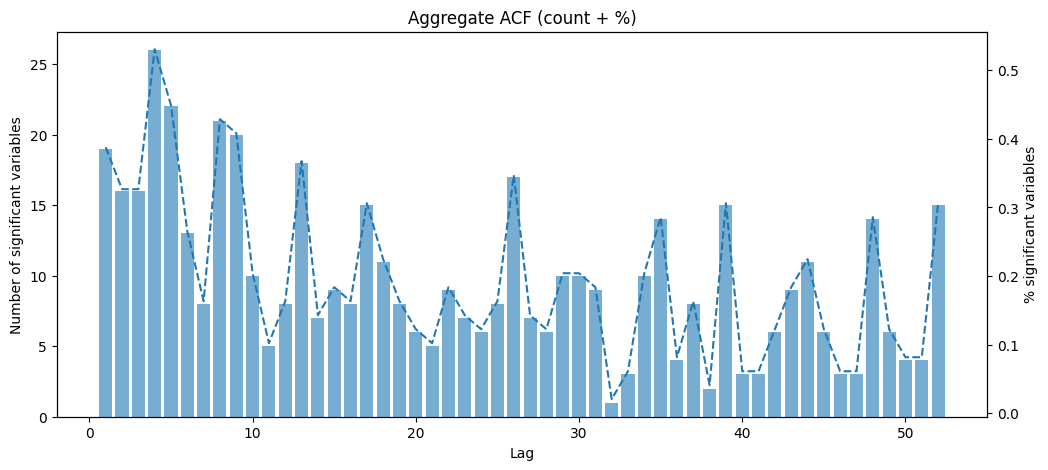

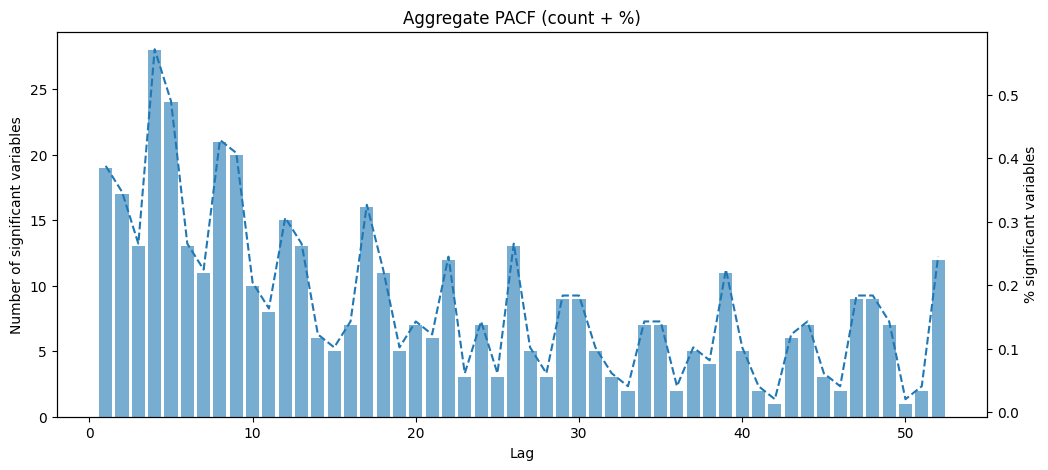

In [8]:
# =====================================================
# ACF SIMPLE: conteo + %
# =====================================================

acf_counts = acf_sig_mat.sum(axis=0)
acf_pct = acf_counts / acf_sig_mat.shape[0]

fig, ax1 = plt.subplots(figsize=(12, 5))

# barras = conteo
ax1.bar(lags, acf_counts, alpha=0.6)
ax1.set_xlabel("Lag")
ax1.set_ylabel("Number of significant variables")

# línea = %
ax2 = ax1.twinx()
ax2.plot(lags, acf_pct, linestyle="--")
ax2.set_ylabel("% significant variables")

plt.title("Aggregate ACF (count + %)")
plt.show()


# =====================================================
# PACF SIMPLE: conteo + %
# =====================================================

pacf_counts = pacf_sig_mat.sum(axis=0)
pacf_pct = pacf_counts / pacf_sig_mat.shape[0]

fig, ax1 = plt.subplots(figsize=(12, 5))

# barras = conteo
ax1.bar(lags, pacf_counts, alpha=0.6)
ax1.set_xlabel("Lag")
ax1.set_ylabel("Number of significant variables")

# línea = %
ax2 = ax1.twinx()
ax2.plot(lags, pacf_pct, linestyle="--")
ax2.set_ylabel("% significant variables")

plt.title("Aggregate PACF (count + %)")
plt.show()

### Variables X

In [9]:
# =====================================================
# CONFIG UNIFORME (semanas) — global
# =====================================================
LAGS   = [1, 2, 4, 8, 13, 26, 52]
DIFF_H = [2, 4, 8, 13, 26, 52] # 1 se hace en loop solo
ROLL_W = [8, 13, 26, 52]

def rolling_z(x: pd.Series, w: int) -> pd.Series:
    mu = x.rolling(w).mean()
    sd = x.rolling(w).std()

    z = (x - mu) / sd
    # si sd==0 (ventana plana) => z=0 en vez de NaN
    z = z.where(sd != 0, 0.0)
    return z

features = {}  # aquí guardamos TODO, sin filtrar ni limpiar


# =====================================================
# BLOCK 1 — LEVEL_LIKE
# Niveles no estacionarios -> cambios + lags + rolling (uniforme)
# =====================================================
for v in LEVEL_LIKE:
    if v not in weekly_df.columns:
        continue
    x = weekly_df[v].astype(float)

    # Base semanal
    pct1 = x.pct_change(1)
    features[f"{v}__pct1"] = pct1

    # Multi-horizonte (momentum)
    for h in DIFF_H:
        pct_h = x.pct_change(h)
        features[f"{v}__pct{h}"] = pct_h

    # Rolling (sobre pct1)
    for w in ROLL_W:
        features[f"{v}__pct1__rollstd{w}"] = pct1.rolling(w).std()
        features[f"{v}__pct1__z{w}"]       = rolling_z(pct1, w)


# =====================================================
# BLOCK 2 — RATE_LIKE
# Ya están en % puntos -> cambios + lags + rolling (uniforme)
# =====================================================
for v in RATE_LIKE:
    if v not in weekly_df.columns:
        continue
    x = weekly_df[v].astype(float)

    # Base semanal
    d1 = x.diff(1)
    features[f"{v}__lvl"] = x
    features[f"{v}__d1"]  = d1

    # Multi-horizonte (cambios acumulados en % puntos)
    for h in DIFF_H:
        d_h = x.diff(h)
        features[f"{v}__d{h}"] = d_h

    # Lags (sobre nivel y cambios)
    for L in LAGS:
        features[f"{v}__lvl__L{L}"] = x.shift(L)

    # Rolling (uniforme)
    for w in ROLL_W:
        # Rolling del nivel (regímenes)
        features[f"{v}__lvl__rollstd{w}"] = x.rolling(w).std()
        features[f"{v}__lvl__z{w}"] = rolling_z(x, w)

        # Rolling del cambio (volatilidad de tasas/spreads)
        features[f"{v}__d1__rollstd{w}"] = d1.rolling(w).std()
        features[f"{v}__d1__z{w}"]       = rolling_z(d1, w)


# =====================================================
# BLOCK 3 — SPECIAL_LIKE
# Índices/vol/condiciones -> cambios + lags + rolling (uniforme)
# =====================================================
for v in SPECIAL_LIKE:
    if v not in weekly_df.columns:
        continue
    x = weekly_df[v].astype(float)

    # Base semanal
    d1 = x.diff(1)
    features[f"{v}__lvl"] = x
    features[f"{v}__d1"]  = d1

    # Multi-horizonte
    for h in DIFF_H:
        d_h = x.diff(h)
        features[f"{v}__d{h}"] = d_h

    # Lags
    for L in LAGS:
        features[f"{v}__lvl__L{L}"] = x.shift(L)

    # Rolling (uniforme) 
    for w in ROLL_W:
        features[f"{v}__lvl__rollstd{w}"] = x.rolling(w).std()
        features[f"{v}__lvl__z{w}"]       = rolling_z(x, w)

        features[f"{v}__d1__rollstd{w}"] = d1.rolling(w).std()
        features[f"{v}__d1__z{w}"]       = rolling_z(d1, w)


# =====================================================
# BLOCK 4 — TREND_LIKE 
# 0–100 acotadas -> cambios + lags + rolling (uniforme)
# =====================================================
for v in TREND_LIKE:
    if v not in weekly_df.columns:
        continue
    x = weekly_df[v].astype(float)

    # Base semanal
    d1 = x.diff(1)
    features[f"{v}__lvl"] = x
    features[f"{v}__d1"]  = d1

    # Multi-horizonte
    for h in DIFF_H:
        d_h = x.diff(h)
        features[f"{v}__d{h}"] = d_h

    # Lags
    for L in LAGS:
        features[f"{v}__lvl__L{L}"] = x.shift(L)

    # Rolling (uniforme) — quitamos rollmean, mantenemos rollstd y z en ventanas largas
    for w in ROLL_W:
        features[f"{v}__lvl__rollstd{w}"] = x.rolling(w).std()
        features[f"{v}__lvl__z{w}"]       = rolling_z(x, w)

        features[f"{v}__d1__rollstd{w}"] = d1.rolling(w).std()
        features[f"{v}__d1__z{w}"]       = rolling_z(d1, w)


# =====================================================
# FINAL: Feature matrix 
# =====================================================
X = pd.DataFrame(features, index=weekly_df.index)

# Ver todas las nuevas features creadas (columnas de X)
print("\nNew features created (X columns):")
print(X.columns)
print("\nX shape:", X.shape)


New features created (X columns):
Index(['SP500__pct1', 'SP500__pct2', 'SP500__pct4', 'SP500__pct8',
       'SP500__pct13', 'SP500__pct26', 'SP500__pct52', 'SP500__pct1__rollstd8',
       'SP500__pct1__z8', 'SP500__pct1__rollstd13',
       ...
       'credit_card_debt__d1__rollstd13', 'credit_card_debt__d1__z13',
       'credit_card_debt__lvl__rollstd26', 'credit_card_debt__lvl__z26',
       'credit_card_debt__d1__rollstd26', 'credit_card_debt__d1__z26',
       'credit_card_debt__lvl__rollstd52', 'credit_card_debt__lvl__z52',
       'credit_card_debt__d1__rollstd52', 'credit_card_debt__d1__z52'],
      dtype='object', length=1247)

X shape: (1135, 1247)


### Limpieza NAN's (Y e X)

In [10]:
# =====================================================
# CLEAN UP Y ONLY
# - Mantiene solo las fechas donde la Y binaria existe
# - Base = X + Y
# - NO limpia X todavía
# =====================================================

print("Y name:", y_bin.name)
print("Original X shape:", X.shape)
print("Original date range:", X.index.min(), "→", X.index.max())

# unir features creadas + Y
df_y = pd.concat([X, y_bin], axis=1)

print("\n[BEFORE dropna on Y]")
print("df_y shape:", df_y.shape)
print("date range:", df_y.index.min(), "→", df_y.index.max())
print("Y NaNs:", df_y[y_bin.name].isna().sum())
print("Y value counts (incluyendo NaN):")
print(df_y[y_bin.name].value_counts(dropna=False).sort_index())

# limpiar SOLO filas donde Y no existe
df_y = df_y.dropna(subset=[y_bin.name])

print("\n[AFTER dropna on Y]")
print("df_y shape:", df_y.shape)
print("date range:", df_y.index.min(), "→", df_y.index.max())
print("Y NaNs:", df_y[y_bin.name].isna().sum())
print("Y value counts:")
print(df_y[y_bin.name].value_counts().sort_index())

Y name: y_SP500_bin_4w
Original X shape: (1135, 1247)
Original date range: 2004-04-02 00:00:00 → 2025-12-26 00:00:00

[BEFORE dropna on Y]
df_y shape: (1135, 1248)
date range: 2004-04-02 00:00:00 → 2025-12-26 00:00:00
Y NaNs: 30
Y value counts (incluyendo NaN):
y_SP500_bin_4w
0.0    228
1.0    877
NaN     30
Name: count, dtype: int64

[AFTER dropna on Y]
df_y shape: (1105, 1248)
date range: 2004-10-01 00:00:00 → 2025-11-28 00:00:00
Y NaNs: 0
Y value counts:
y_SP500_bin_4w
0.0    228
1.0    877
Name: count, dtype: int64


In [11]:
# =====================================================
# CLEAN UP X
# =====================================================

print("\n[BEFORE dropna on X]")
print("df_y shape:", df_y.shape)
print("date range:", df_y.index.min(), "→", df_y.index.max())
print("Total X NaNs:", df_y[X.columns].isna().sum().sum())
print("Rows with any X NaN:", df_y[X.columns].isna().any(axis=1).sum())
print("Y value counts:")
print(df_y[y_bin.name].value_counts().sort_index())

df_xy = df_y.dropna(subset=X.columns).copy()

print("\n[AFTER dropna on X]")
print("df_xy shape:", df_xy.shape)
print("date range:", df_xy.index.min(), "→", df_xy.index.max())
print("Total X NaNs:", df_xy[X.columns].isna().sum().sum())
print("Rows with any X NaN:", df_xy[X.columns].isna().any(axis=1).sum())
print("Y value counts:")
print(df_xy[y_bin.name].value_counts().sort_index())


[BEFORE dropna on X]
df_y shape: (1105, 1248)
date range: 2004-10-01 00:00:00 → 2025-11-28 00:00:00
Total X NaNs: 6264
Rows with any X NaN: 27
Y value counts:
y_SP500_bin_4w
0.0    228
1.0    877
Name: count, dtype: int64

[AFTER dropna on X]
df_xy shape: (1078, 1248)
date range: 2005-04-08 00:00:00 → 2025-11-28 00:00:00
Total X NaNs: 0
Rows with any X NaN: 0
Y value counts:
y_SP500_bin_4w
0.0    221
1.0    857
Name: count, dtype: int64


## Analisis

In [12]:
CUTOFF_DATE = "2025-01-01"

df_xy_full = df_xy.copy()                             # copia completa para export final
df_xy = df_xy.loc[df_xy.index < CUTOFF_DATE].copy()   # df_xy sobreescrito con la versión filtrada

print("Full shape:", df_xy_full.shape)
print("FS shape:", df_xy.shape)
print("FS max date:", df_xy.index.max().strftime("%Y-%m-%d"))

Full shape: (1078, 1248)
FS shape: (1030, 1248)
FS max date: 2024-12-27


### Varianza nula (casi)

In [13]:
VAR_THRESHOLD = 1e-1 

X_xy = df_xy[X.columns].copy()

# -------- robust scaling
med = X_xy.median()
iqr = X_xy.quantile(0.75) - X_xy.quantile(0.25)
iqr = iqr.replace(0, np.nan)

X_scaled = (X_xy - med) / iqr

# -------- varianza sobre escalado
var_s = X_scaled.var()

low_var_cols = var_s[var_s < VAR_THRESHOLD].index.tolist()

print("Original df_xy shape:", df_xy.shape)
print("N X features:", X_xy.shape[1])
print("Low-variance features:", len(low_var_cols))

# -------- eliminar en X original
X_xy_v1 = X_xy.drop(columns=low_var_cols)
df_xy_v1 = pd.concat([X_xy_v1, df_xy[[y_bin.name]]], axis=1)

print("\n[AFTER low-variance filter]")
print("df_xy_v1 shape:", df_xy_v1.shape)
print("Remaining X features:", X_xy_v1.shape[1])
print("Y value counts:")
print(df_xy_v1[y_bin.name].value_counts().sort_index())

print("\nLow-variance features (first 30):")
print(low_var_cols[:30])

Original df_xy shape: (1030, 1248)
N X features: 1247
Low-variance features: 0

[AFTER low-variance filter]
df_xy_v1 shape: (1030, 1248)
Remaining X features: 1247
Y value counts:
y_SP500_bin_4w
0.0    213
1.0    817
Name: count, dtype: int64

Low-variance features (first 30):
[]


### Corr X - X

In [14]:
CORR_THRESHOLD = 0.70

X_v1 = df_xy_v1.drop(columns=[y_bin.name]).copy()

corr_mat = X_v1.corr().abs()

# triángulo superior
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

# columnas a eliminar
to_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

print("Total features:", X_v1.shape[1])
print("Features to drop:", len(to_drop))

print("\nFirst features to drop:")
print(to_drop[:30])

# aplicar drop
X_v2 = X_v1.drop(columns=to_drop)
df_xy_v2 = pd.concat([X_v2, df_xy_v1[[y_bin.name]]], axis=1)

print("\n[AFTER correlation filter]")
print("df_xy_v2 shape:", df_xy_v2.shape)
print("Remaining X features:", X_v2.shape[1])
print("Y value counts:")
print(df_xy_v2[y_bin.name].value_counts().sort_index())

Total features: 1247
Features to drop: 1051

First features to drop:
['SP500__pct13', 'SP500__pct26', 'SP500__pct1__z8', 'SP500__pct1__rollstd13', 'SP500__pct1__z13', 'SP500__pct1__rollstd26', 'SP500__pct1__z26', 'SP500__pct1__rollstd52', 'SP500__pct1__z52', 'WTI_Crude_Oil__pct2', 'WTI_Crude_Oil__pct8', 'WTI_Crude_Oil__pct13', 'WTI_Crude_Oil__pct1__z8', 'WTI_Crude_Oil__pct1__rollstd13', 'WTI_Crude_Oil__pct1__z13', 'WTI_Crude_Oil__pct1__rollstd26', 'WTI_Crude_Oil__pct1__z26', 'WTI_Crude_Oil__pct1__rollstd52', 'WTI_Crude_Oil__pct1__z52', 'Natural_Gas__pct2', 'Natural_Gas__pct4', 'Natural_Gas__pct13', 'Natural_Gas__pct1__z8', 'Natural_Gas__pct1__rollstd13', 'Natural_Gas__pct1__z13', 'Natural_Gas__pct1__rollstd26', 'Natural_Gas__pct1__z26', 'Natural_Gas__pct1__rollstd52', 'Natural_Gas__pct1__z52', 'Copper__pct4']

[AFTER correlation filter]
df_xy_v2 shape: (1030, 197)
Remaining X features: 196
Y value counts:
y_SP500_bin_4w
0.0    213
1.0    817
Name: count, dtype: int64


### Mutual Info (X - Y) (medida general) (paralelo_A)

In [15]:
from sklearn.feature_selection import mutual_info_classif

# separar X e Y
X_v2 = df_xy_v2.drop(columns=[y_bin.name]).copy()
y_v2 = df_xy_v2[y_bin.name].copy()

# calcular MI
mi = mutual_info_classif(X_v2, y_v2, random_state=42)

mi_series = pd.Series(mi, index=X_v2.columns)

# ordenar
mi_series = mi_series.sort_values(ascending=False)

print("\nTop MI features:")
print(mi_series.head(10))


Top MI features:
CPI_YoY__lvl__L52                        0.179585
Consumer_Sentiment__pct26                0.177889
CPI__pct4                                0.175727
CPI__pct52                               0.173267
Core_CPI__pct4                           0.163716
Industrial_Production__pct1__rollstd8    0.163011
CPI__pct1__rollstd8                      0.160268
Industrial_Production__pct52             0.155621
Industrial_Production__pct26             0.154511
Consumer_Sentiment__pct52                0.137622
dtype: float64


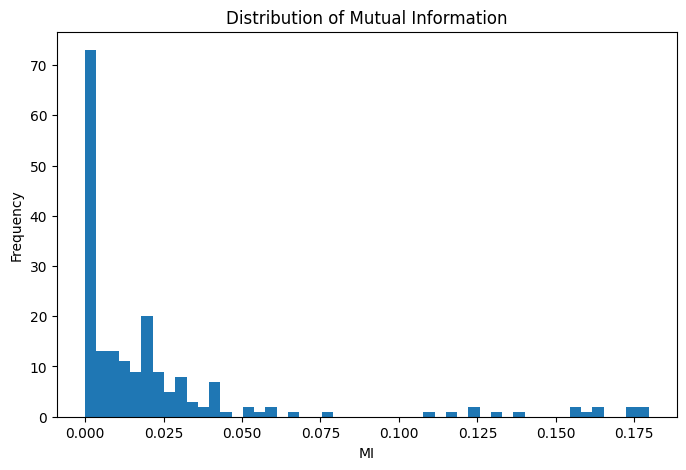

In [16]:
mi_vals = mi_series.values

plt.figure(figsize=(8,5))
plt.hist(mi_vals, bins=50)
plt.title("Distribution of Mutual Information")
plt.xlabel("MI")
plt.ylabel("Frequency")
plt.show()

In [17]:
MI_MIN = 0.025   # <- cambia este valor

# info antes
n_before = len(mi_series)
# filtrar
mi_series_f = mi_series[mi_series >= MI_MIN].copy()

# info después
n_after = len(mi_series_f)
n_removed = n_before - n_after

print("\n[AFTER MI MIN FILTER]")
print("MI_MIN:", MI_MIN)
print("Before:", n_before)
print("After:", n_after)
print("Removed:", n_removed)


[AFTER MI MIN FILTER]
MI_MIN: 0.025
Before: 196
After: 48
Removed: 148


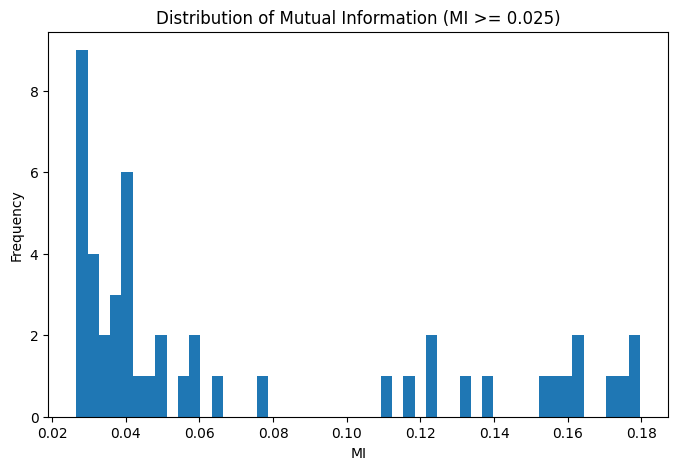

In [18]:
# gráfico nuevo
plt.figure(figsize=(8, 5))
plt.hist(mi_series_f.values, bins=50)
plt.title(f"Distribution of Mutual Information (MI >= {MI_MIN})")
plt.xlabel("MI")
plt.ylabel("Frequency")
plt.show()

# dataset filtrado
vars_mi  = mi_series_f.index.tolist()

### Corr X - Y (medida lineal) (paralelo_A)


Top CORR features:
NFCI__d1__z8                     0.251259
NFCI__d1                         0.232960
NFCI__lvl__z8                    0.198347
CPI__pct52                       0.171995
resume_template__d52             0.141363
resume_template__d26             0.129053
Bank_Reserves__pct1__rollstd8    0.128048
credit_card_debt__d26            0.119283
Japan_Policy_Rate__lvl           0.117500
Natural_Gas__pct52               0.114394
dtype: float64


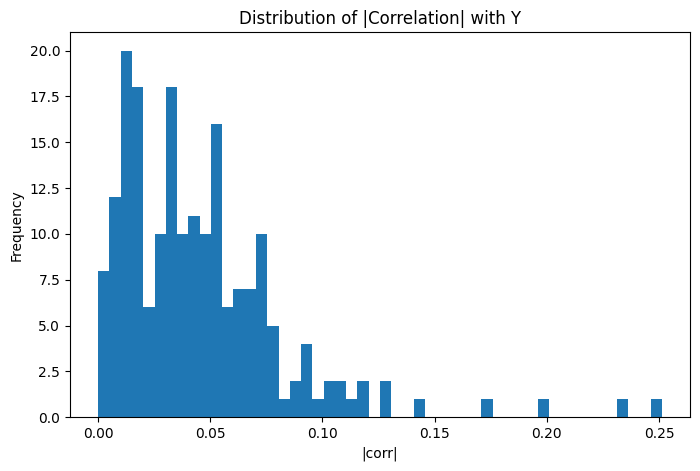


[AFTER CORR MIN FILTER]
CORR_MIN: 0.1
Before: 196
After: 14
Removed: 182


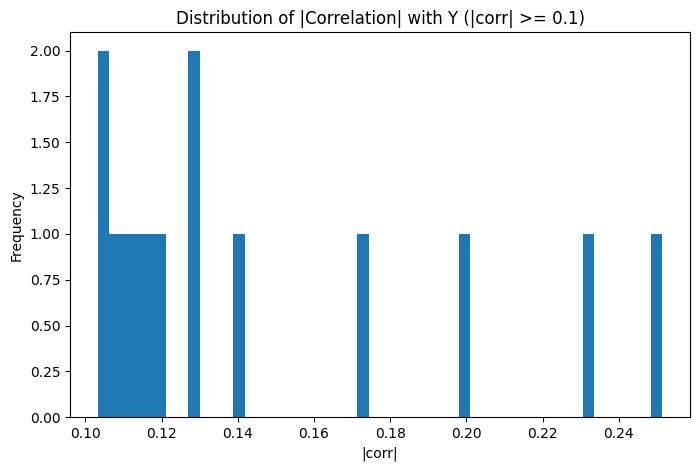

In [19]:
# =====================================================
# CORRELATION (X - Y) EN PARALELO
# =====================================================

# correlación absoluta con Y
corr_series = X_v2.corrwith(y_v2).abs().sort_values(ascending=False)

print("\nTop CORR features:")
print(corr_series.head(10))

# gráfico distribución
plt.figure(figsize=(8, 5))
plt.hist(corr_series.values, bins=50)
plt.title("Distribution of |Correlation| with Y")
plt.xlabel("|corr|")
plt.ylabel("Frequency")
plt.show()

# threshold corr
CORR_MIN = 0.10   # <- cambia este valor

# info antes
n_before_corr = len(corr_series)

# filtrar
corr_series_f = corr_series[corr_series >= CORR_MIN].copy()
vars_corr = corr_series_f.index.tolist()

# info después
n_after_corr = len(corr_series_f)
n_removed_corr = n_before_corr - n_after_corr

print("\n[AFTER CORR MIN FILTER]")
print("CORR_MIN:", CORR_MIN)
print("Before:", n_before_corr)
print("After:", n_after_corr)
print("Removed:", n_removed_corr)

# gráfico nuevo
plt.figure(figsize=(8, 5))
plt.hist(corr_series_f.values, bins=50)
plt.title(f"Distribution of |Correlation| with Y (|corr| >= {CORR_MIN})")
plt.xlabel("|corr|")
plt.ylabel("Frequency")
plt.show()

In [20]:
# =====================================================
# CHEQUEO: variables en CORR que NO están en MI
# =====================================================

vars_corr_not_in_mi = sorted(list(set(vars_corr) - set(vars_mi)))
vars_mi_not_in_corr = sorted(list(set(vars_mi) - set(vars_corr)))
vars_both = sorted(list(set(vars_mi) & set(vars_corr)))

print("\n[MI vs CORR]")
print("vars_mi:", len(vars_mi))
print("vars_corr:", len(vars_corr))
print("in both:", len(vars_both))
print("in corr not in mi:", len(vars_corr_not_in_mi))
print("in mi not in corr:", len(vars_mi_not_in_corr))

print("\nFirst vars in corr not in mi:")
print(vars_corr_not_in_mi[:30])


[MI vs CORR]
vars_mi: 48
vars_corr: 14
in both: 8
in corr not in mi: 6
in mi not in corr: 40

First vars in corr not in mi:
['NFCI__lvl__z8', 'Natural_Gas__pct52', 'Short_Term_Credit_Spread__lvl__L26', 'Spread_10Y_3M__lvl__rollstd8', 'WTI_Crude_Oil__pct52', 'resume_template__d26']


In [21]:
# =====================================================
# UNION FINAL
# =====================================================

vars_final = sorted(list(set(vars_mi) | set(vars_corr)))

X_v3 = X_v2[vars_final].copy()
df_xy_v3 = pd.concat([X_v3, y_v2], axis=1)

print("\n[FINAL DATASET AFTER MI OR CORR]")
print("Final features:", len(vars_final))
print("Added by corr only:", len(vars_corr_not_in_mi))
print("df_xy_v3 shape:", df_xy_v3.shape)


[FINAL DATASET AFTER MI OR CORR]
Final features: 54
Added by corr only: 6
df_xy_v3 shape: (1030, 55)


### WRAPPER

Starting features: 54
Iter 1: before=54, dropped=6, after=48
Iter 2: before=48, dropped=5, after=43
Iter 3: before=43, dropped=5, after=38
Iter 4: before=38, dropped=5, after=33
Iter 5: before=33, dropped=3, after=30

[FINAL DATASET AFTER CATBOOST WRAPPER]
Final features: 30
df_xy_v4 shape: (1030, 31)

Top final selected features:
                           feature  importance
                      NFCI__d1__z8    7.904057
                          NFCI__d1    6.224824
     US_2Y_Treasury__lvl__rollstd8    5.878490
  Building_Permits__pct1__rollstd8    5.134158
              WTI_Crude_Oil__pct52    4.812647
  credit_card_debt__lvl__rollstd52    3.915486
   US_10Y_Treasury__lvl__rollstd52    3.834962
                        RV_30D__d1    3.691268
              Gold__pct1__rollstd8    3.518994
           CPI_YoY__lvl__rollstd52    3.502263
                     NFCI__lvl__z8    3.424833
Consumer_Sentiment__pct1__rollstd8    3.194006
                Natural_Gas__pct52    3.052291
         

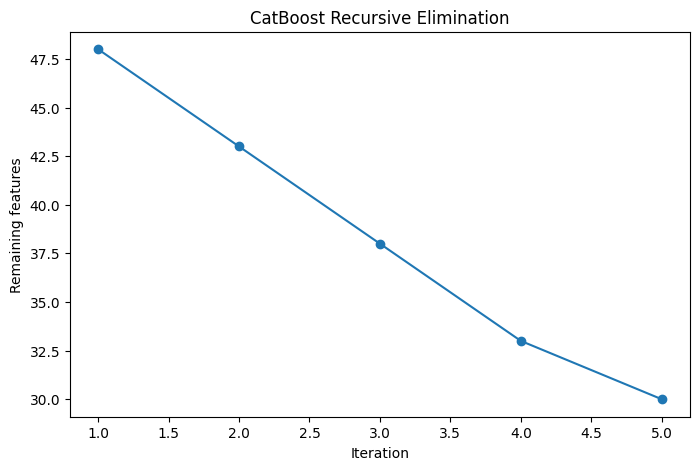

In [22]:
# =====================================================
# WRAPPER FEATURE SELECTION — RECURSIVE ELIMINATION WITH CATBOOST
# Base: df_xy_v3
# =====================================================

from catboost import CatBoostClassifier

# -----------------------------
# DATA
# -----------------------------
X_wrap = df_xy_v3.drop(columns=[y_bin.name]).copy()
y_wrap = df_xy_v3[y_bin.name].copy()

print("Starting features:", X_wrap.shape[1])

# -----------------------------
# CONFIG
# -----------------------------
FINAL_N_FEATURES = 30      
DROP_FRAC = 0.10           # <- elimina 10% de las peores en cada iteración
MIN_DROP = 5               # <- mínimo a eliminar por iteración
RANDOM_STATE = 42

# -----------------------------
# TRACKING
# -----------------------------
history = []
current_features = list(X_wrap.columns)

# -----------------------------
# RECURSIVE ELIMINATION
# -----------------------------
iteration = 0

CLASS_WEIGHTS = [3, 1]

while len(current_features) > FINAL_N_FEATURES:
    iteration += 1

    X_curr = X_wrap[current_features]
    
    model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=CLASS_WEIGHTS,   # para darle peso a los pocos 0's
        verbose=False,
        random_seed=RANDOM_STATE,
        allow_writing_files=False
    )

    model.fit(X_curr, y_wrap)

    importances = model.get_feature_importance()
    imp_df = (
        pd.DataFrame({
            "feature": current_features,
            "importance": importances
        })
        .sort_values("importance", ascending=True)
        .reset_index(drop=True)
    )

    n_current = len(current_features)
    n_to_drop = max(MIN_DROP, int(np.ceil(n_current * DROP_FRAC)))

    # no pasarse del objetivo final
    n_to_drop = min(n_to_drop, n_current - FINAL_N_FEATURES)

    drop_features = imp_df.head(n_to_drop)["feature"].tolist()
    keep_features = imp_df.iloc[n_to_drop:]["feature"].tolist()

    history.append({
        "iteration": iteration,
        "before": n_current,
        "dropped": n_to_drop,
        "after": len(keep_features)
    })

    print(f"Iter {iteration}: before={n_current}, dropped={n_to_drop}, after={len(keep_features)}")

    current_features = keep_features

# -----------------------------
# FINAL DATASET
# -----------------------------
selected_features_cat = current_features

X_v4 = X_wrap[selected_features_cat].copy()
df_xy_v4 = pd.concat([X_v4, y_wrap], axis=1)

print("\n[FINAL DATASET AFTER CATBOOST WRAPPER]")
print("Final features:", len(selected_features_cat))
print("df_xy_v4 shape:", df_xy_v4.shape)

# -----------------------------
# FINAL IMPORTANCE ON SELECTED SET
# -----------------------------
final_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=CLASS_WEIGHTS,
    train_dir=None,
    verbose=False,
    random_seed=RANDOM_STATE,
    allow_writing_files=False
)

final_model.fit(X_v4, y_wrap)

final_imp = pd.DataFrame({
    "feature": selected_features_cat,
    "importance": final_model.get_feature_importance()
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop final selected features:")
print(final_imp.head(20).to_string(index=False))

# -----------------------------
# HISTORY TABLE
# -----------------------------
history_df = pd.DataFrame(history)

print("\nElimination history:")
print(history_df.to_string(index=False))

# -----------------------------
# OPTIONAL: HISTORY PLOT
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(history_df["iteration"], history_df["after"], marker="o")
plt.title("CatBoost Recursive Elimination")
plt.xlabel("Iteration")
plt.ylabel("Remaining features")
plt.show()

### Downlaod CSV

In [23]:
# =====================================================
# FULL DATASET WITH SELECTED FEATURES
# =====================================================
X_v4_full = df_xy_full[selected_features_cat].copy()
y_full = df_xy_full[[y_bin.name]].copy()

df_xy_v4_full = pd.concat([X_v4_full, y_full], axis=1)

# =====================================================
# SAVE CSV
# =====================================================
file_path = "prepared_data/reduced_vars.csv"

df_xy_v4_full.to_csv(file_path, index=True)

print("Saved to:", file_path)
print("Shape:", df_xy_v4_full.shape)
print("Date range:", df_xy_v4_full.index.min(), "→", df_xy_v4_full.index.max())

Saved to: prepared_data/reduced_vars.csv
Shape: (1078, 31)
Date range: 2005-04-08 00:00:00 → 2025-11-28 00:00:00


In [24]:
print("FS max date (selection):", df_xy.index.max())
print("FULL max date (export):", df_xy_v4_full.index.max())

FS max date (selection): 2024-12-27 00:00:00
FULL max date (export): 2025-11-28 00:00:00
